<div style="font-size: 28px; font-weight: bold; text-align: center; margin-bottom: 20px;">
    Отчёт по лабораторной работе
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Дисциплина:</b> <i>Цифровая обработка сигналов</i>
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Лабораторная работа №3:</b> <i>Определение музыкальных трезвучий</i>
</div>


<hr>

<div style="font-size: 20px; margin-bottom: 15px;">
    <b>Вариант:</b> <i>11</i>
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Преподаватель:</b> Рыбин Сергей Витальевич
</div>

<div style="font-size: 20px; margin-bottom: 5px;">
    <b>Студент:</b> Рябой Евгений Э., группа М4121
</div>

<div style="font-size: 20px; margin-bottom: 10px;">
    <b>Дата выдачи:</b> 12.01.2026
    <br>
    <b>Дата исполнения:</b> 15.01.2026
</div>

<hr>


## **Постановка задачи**


**Входные данные**: 
1. Аудио сигнал одного из трезвучий с частотой дискретизации $𝐹_𝑑$ = 16000 Hz, 16 Bit, Mono, PCM wave file.
2. Длительность сигнала 5 секунд, основной тон (𝐹1) неизвестен.
3. Каждый звук трезвучия построен алгоритмом Карплуса–Стронга

**Задача**: Определить частоты трезвучия в данном аудио сигнале.


## **Описание системы тонального набора**

Таблица трезвучий с номерами нот (система нумерации от C=0), 12 мажорных и 12 минорных

| Мажорная тональность | Номера нот | Минорная тональность | Номера нот |
|----------------------|------------|----------------------|------------|
| До мажор             | {0, 4, 7}  | До минор             | {0, 3, 7}  |
| До# мажор            | {1, 5, 8}  | До# минор            | {1, 4, 8}  |
| Ре мажор             | {2, 6, 9}  | Ре минор             | {2, 5, 9}  |
| Ре# мажор            | {3, 7, 10} | Ре# минор            | {3, 6, 10} |
| Ми мажор             | {4, 8, 11} | Ми минор             | {4, 7, 11} |
| Фа мажор             | {5, 9, 12} | Фа минор             | {5, 8, 12} |
| Фа# мажор            | {6, 10, 13}| Фа# минор            | {6, 9, 13} |
| Соль мажор           | {7, 11, 14}| Соль минор           | {7, 10, 14}|
| Соль# мажор          | {8, 12, 15}| Соль# минор          | {8, 11, 15}|
| Ля мажор             | {9, 13, 16}| Ля минор             | {9, 12, 16}|
| Ля# мажор            | {10, 14, 17}| Ля# минор           | {10, 13, 17}|
| Си мажор             | {11, 15, 18}| Си минор            | {11, 14, 18}|

**Пояснение:**  
Номера нот в таблице указывают сдвиг (в полутонах) относительно базовой частоты $F_0$ \
Например, для трезвучия **До# мажор**: $\{1, 5, 8\}$ получаем:

$$
F_1 = \sqrt[12]{2}^{\,1} \cdot F_0 = 2^{\frac{1}{12}} \cdot F_0
$$

$$
F_2 = \sqrt[12]{2}^{\,5} \cdot F_0 = 2^{\frac{5}{12}} \cdot F_0
$$

$$
F_3 = \sqrt[12]{2}^{\,8} \cdot F_0 = 2^{\frac{8}{12}} \cdot F_0
$$

где $\sqrt[12]{2}$ - коэффициент увеличения частоты на один полутон.

В качестве базовой частоты часто берут **До малой октавы** (C3) - $F_0 = 130.82$ Гц.

**Формулы построения трезвучий:**

- Мажорное трезвучие: $\{T,\ T+4,\ T+7\}$
- Минорное трезвучие: $\{T,\ T+3,\ T+7\}$

где $T$ - номер тоники (0 для До, 1 для До# и т.д.)

## 0 Импорты

In [1]:
import os
import wave
from math import pi, cos, log2


import librosa
import numpy as np
import IPython.display as ipd
import matplotlib.pyplot as plt
from scipy.signal import freqz, find_peaks

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn-v0_8-whitegrid')   # Стильная сетка
plt.rcParams['figure.figsize'] = (10, 5)  # Размер по умолчанию
plt.rcParams['font.size'] = 10            # Размер шрифта
plt.rcParams['axes.labelsize'] = 12       # Размер подписей осей
plt.rcParams['axes.titlesize'] = 14       # Размер заголовков

# Для еще лучшего качества (опционально)
plt.rcParams['figure.dpi'] = 150          # Разрешение
plt.rcParams['savefig.dpi'] = 300         # Разрешение при сохранении
plt.rcParams['lines.linewidth'] = 1.5     # Толщина линий

In [3]:
import sys
print(f"Python=={sys.version.split()[0]}")

Python==3.12.12


In [4]:
def print_versions(*modules):
    for m in modules:
        print(f"{m.__name__}=={m.__version__}")

print_versions(librosa, plt.matplotlib, np)

librosa==0.11.0
matplotlib==3.10.7
numpy==2.2.6


## 1 Выполнение работы

### 1.0 Просмотр информации о файле

In [5]:
def print_wav_info(filepath: str) -> None:
    if not os.path.isfile(filepath):
        raise FileNotFoundError(f"Файл '{filepath}' не найден.")

    with wave.open(filepath, 'rb') as wav_file:
        sample_rate = wav_file.getframerate()   # Частота дискретизации (Гц)
        num_channels = wav_file.getnchannels()  # Количество каналов
        sample_width = wav_file.getsampwidth()  # Размер сэмпла в байтах
        bit_depth = sample_width * 8            # Глубина квантования (бит)
        num_frames = wav_file.getnframes()      # Общее количество кадров (сэмплов на канал)

        print(f"Частота дискретизации: {sample_rate} Гц")
        print(f"Количество каналов: {num_channels}")
        print(f"Размер сэмпла: {sample_width} байт(а)")
        print(f"Глубина квантования: {bit_depth} бит")
        print(f"Общее количество сэмплов: {num_frames}")
        print(f"Длительность: {num_frames / sample_rate:.2f} секунд")

In [6]:
path_audio_file = "data/DTLab11.wav"
print_wav_info(filepath=path_audio_file)

Частота дискретизации: 16000 Гц
Количество каналов: 1
Размер сэмпла: 2 байт(а)
Глубина квантования: 16 бит
Общее количество сэмплов: 80000
Длительность: 5.00 секунд


### 1.1 Считывание аудиосигнала

Основные параметры [`librosa.load`](https://librosa.org/doc/0.11.0/generated/librosa.load.html)

Сигнатура:  
`librosa.load(path, *, sr=22050, mono=True, offset=0.0, duration=None, dtype=np.float32, res_type='soxr_hq')`

1. **`path`** - путь/источник аудио (строка, `pathlib.Path`, файловый объект и т. п.)
2. **`sr`** - целевая частота дискретизации (**по умолчанию `22050` Гц**; `None` - сохранить "родную" частоту файла)
3. **`mono`** - сводить в моно (**по умолчанию `True`**)
4. **`offset`** - начать чтение с этой секунды (**по умолчанию `0.0`**)
5. **`duration`** - длительность чтения в секундах (**по умолчанию `None`**; до конца файла)
6. **`dtype`** - тип выходного массива (**по умолчанию `np.float32`**)
7. **`res_type`** - тип ресемплера (**по умолчанию `'soxr_hq'`**)

Возвращает
1. **`y`** - аудиоданные (`numpy.ndarray`, форма `(n,)` для моно или `(…, n)` для мультиканала при `mono=False`)
2. **`sr`** - фактическая частота дискретизации (`int`)


In [7]:
audio_data, original_sample_rate = librosa.load(
    path=path_audio_file, 
    sr=None, 
    mono=True, 
    offset=0.0, 
    duration=100.0, 
    res_type='soxr_vhq'
)

print(f"Частота дискретизации: {original_sample_rate} Гц")
print(f"Тип данных после загрузки: {audio_data.dtype}")
print(f"Диапазон амплитуд: [{audio_data.min():.4f}, {audio_data.max():.4f}]")
print(f"Общее количество сэмплов: {len(audio_data)}")
print(f"Длительность: {len(audio_data) / original_sample_rate:.2f} секунд")

Частота дискретизации: 16000 Гц
Тип данных после загрузки: float32
Диапазон амплитуд: [-1.0000, 1.0000]
Общее количество сэмплов: 80000
Длительность: 5.00 секунд


#### Визуализируем и прослушаем

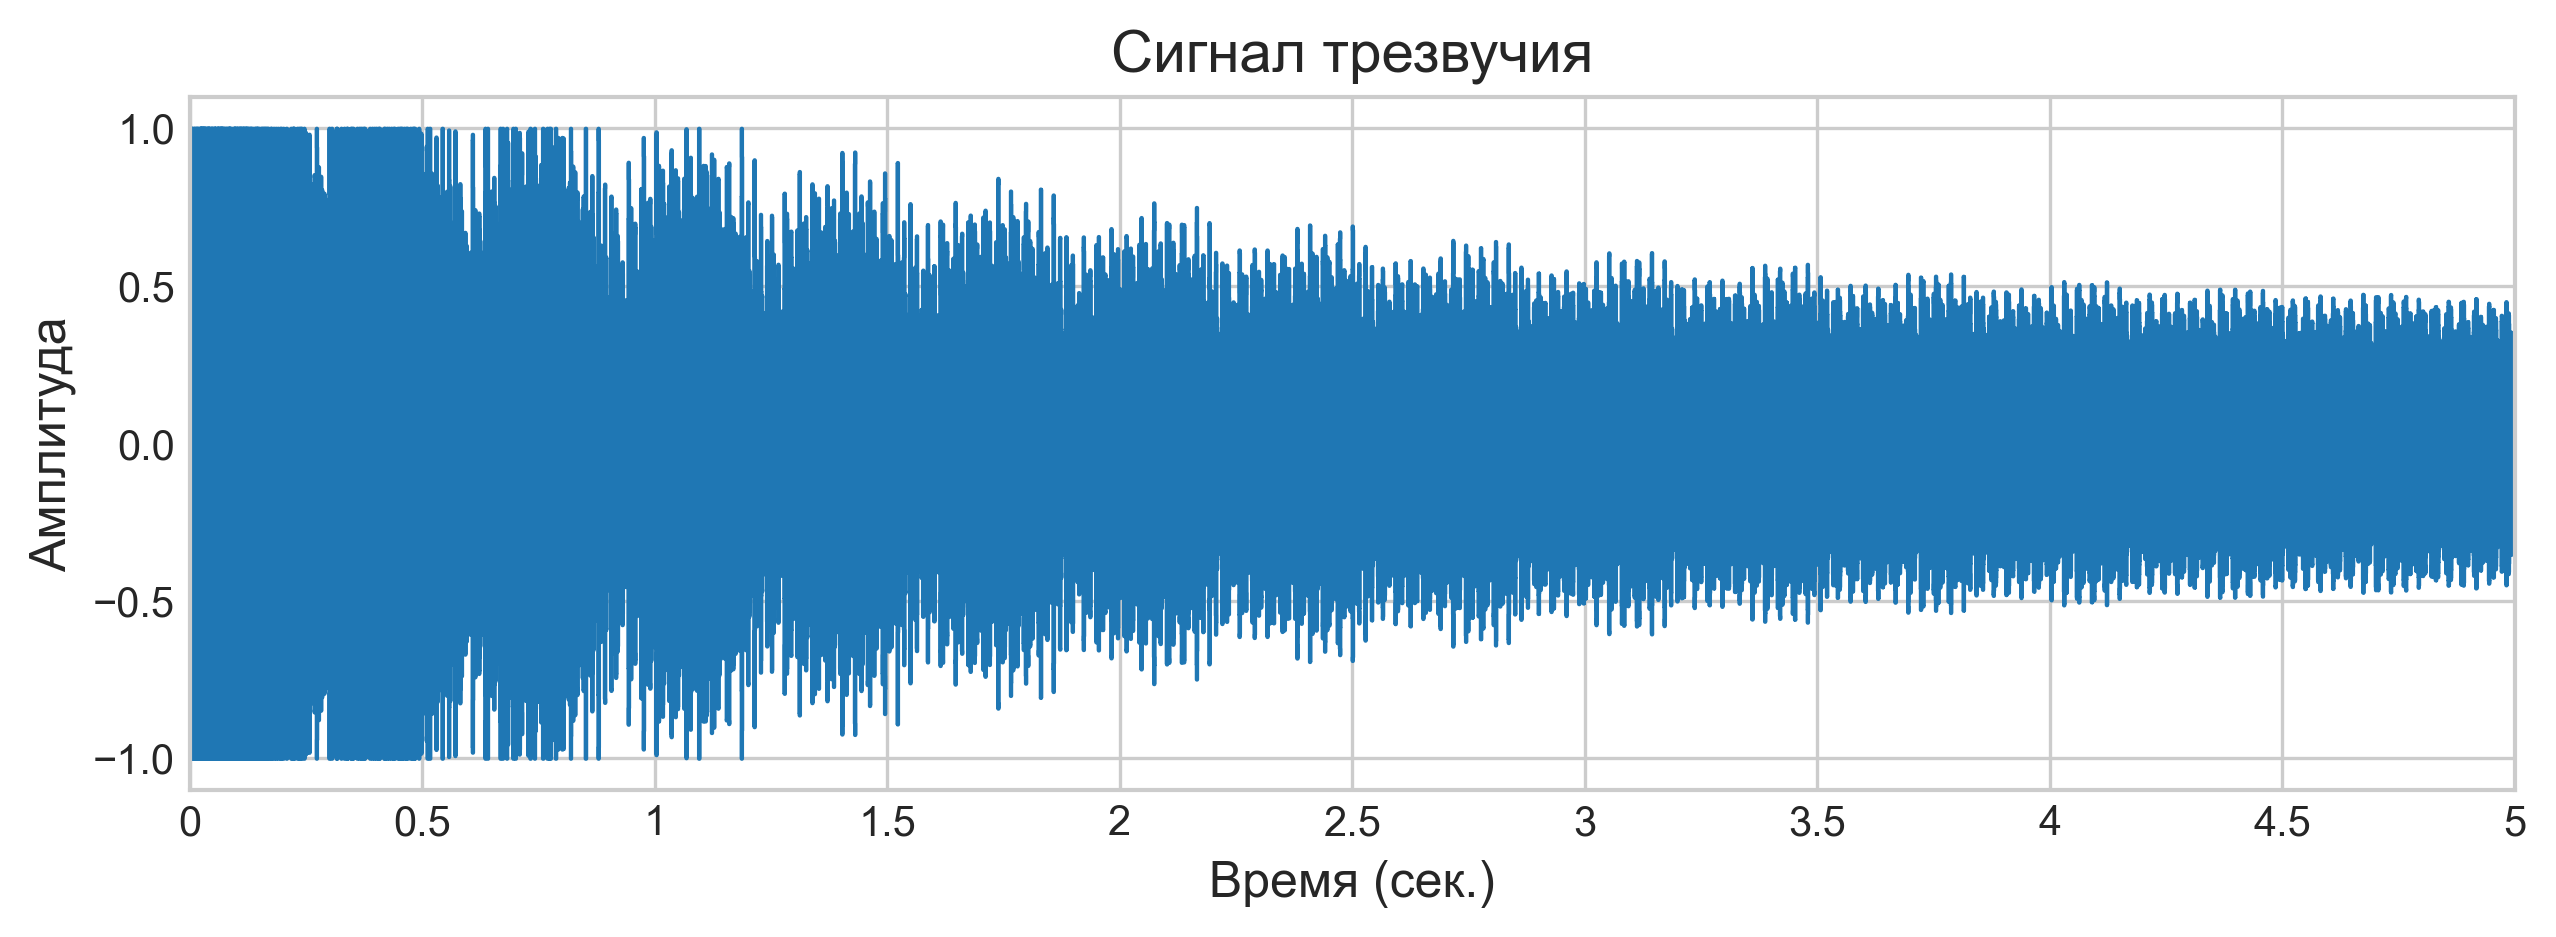

Оригинал (16000 Гц):


In [8]:
plt.figure(figsize=(10, 3))
librosa.display.waveshow(audio_data, sr=original_sample_rate)
plt.title("Сигнал трезвучия")
plt.xlabel("Время (сек.)")
plt.ylabel("Амплитуда")
plt.xticks(np.arange(0, 5.01, 0.5))
plt.xlim(0, 5.0)
plt.show()

print(f"Оригинал ({original_sample_rate} Гц):")
ipd.Audio(data=audio_data, rate=original_sample_rate)

##### Функции для спектрограммы

In [14]:
# Строим и визуализируем спектрограмму (с параметрами по умолчанию)
def Spectrogram(data, stitle, sr=44100):
    # data - исходные данные
    # stitle - название сигнала 
    # Строим спектрограмму    
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))

    # Визуализируем спектрограмму
    fig, ax = plt.subplots(figsize=(14, 3))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='linear', ax=ax)
    ax.set(title=stitle + ' Спектрограмма. Линейный масштаб')
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    plt.ylabel("Частота (Гц)")
    
    fig, ax = plt.subplots(figsize=(14, 3))
    img = librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='log', ax=ax)
    ax.set(title=stitle + ' Спектрограмма. Логарифмический масштаб')
    fig.colorbar(img, ax=ax, format="%+2.f dB")
    plt.ylabel("Частота (Гц)")
    plt.xlabel("Время (сек.)")

In [21]:
def plot_spectra(
        data, 
        name="Сигнал", 
        color="tab:blue", 
        n_fft=4096, 
        sr=22050,
        start=5000,
        plot_instant=True, 
        plot_log=True,
        xlim_min=None,    # нижний предел частоты
        xlim_max=None     # верхний предел частоты
    ):
    
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)

    # Мгновенный спектр
    if plot_instant:
        frame = data[start:start+n_fft]
        sp_inst = np.abs(librosa.stft(frame, n_fft=n_fft, hop_length=n_fft+1))
        sp_inst = sp_inst[:, 0]
        sp_inst_log = librosa.amplitude_to_db(sp_inst, ref=np.max)

    # Средний спектр
    sp = np.abs(librosa.stft(data, n_fft=n_fft, hop_length=n_fft//4))
    sp_mean = np.mean(sp, axis=1)
    sp_mean_log = librosa.amplitude_to_db(sp_mean, ref=np.max)

    # Выбор количества подграфиков
    num_plots = (1 if plot_instant else 0) \
              + (1 if plot_instant and plot_log else 0) \
              + 1 + (1 if plot_log else 0)

    plt.figure(figsize=(18, 4 * num_plots))
    plot_index = 1

    def set_xlim():
        if xlim_min is not None or xlim_max is not None:
            plt.xlim(
                xlim_min if xlim_min is not None else 0,
                xlim_max if xlim_max is not None else freqs[-1]
            )

    # Мгновенный линейный
    if plot_instant:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} - Мгновенный амплитудный спектр")
        plt.plot(freqs, sp_inst, color=color)
        plt.ylabel("Амплитуда")
        plt.grid(True)
        set_xlim()
        plot_index += 1

    # Мгновенный лог
    if plot_instant and plot_log:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} - Мгновенный логарифмический спектр")
        plt.plot(freqs, sp_inst_log, color=color)
        plt.ylabel("Амплитуда (дБ)")
        plt.grid(True)
        set_xlim()
        plot_index += 1

    # Средний линейный
    plt.subplot(num_plots, 1, plot_index)
    plt.title(f"{name} - Средний амплитудный спектр")
    plt.plot(freqs, sp_mean, color=color)
    plt.ylabel("Амплитуда")
    plt.xlabel("Частота (Гц)")
    plt.grid(True)
    set_xlim()
    plot_index += 1

    # Средний лог
    if plot_log:
        plt.subplot(num_plots, 1, plot_index)
        plt.title(f"{name} - Средний логарифмический спектр")
        plt.plot(freqs, sp_mean_log, color=color)
        plt.ylabel("Амплитуда (дБ)")
        plt.xlabel("Частота (Гц)")
        plt.grid(True)
        set_xlim()

    plt.tight_layout()
    plt.show()

##### Демонстрация

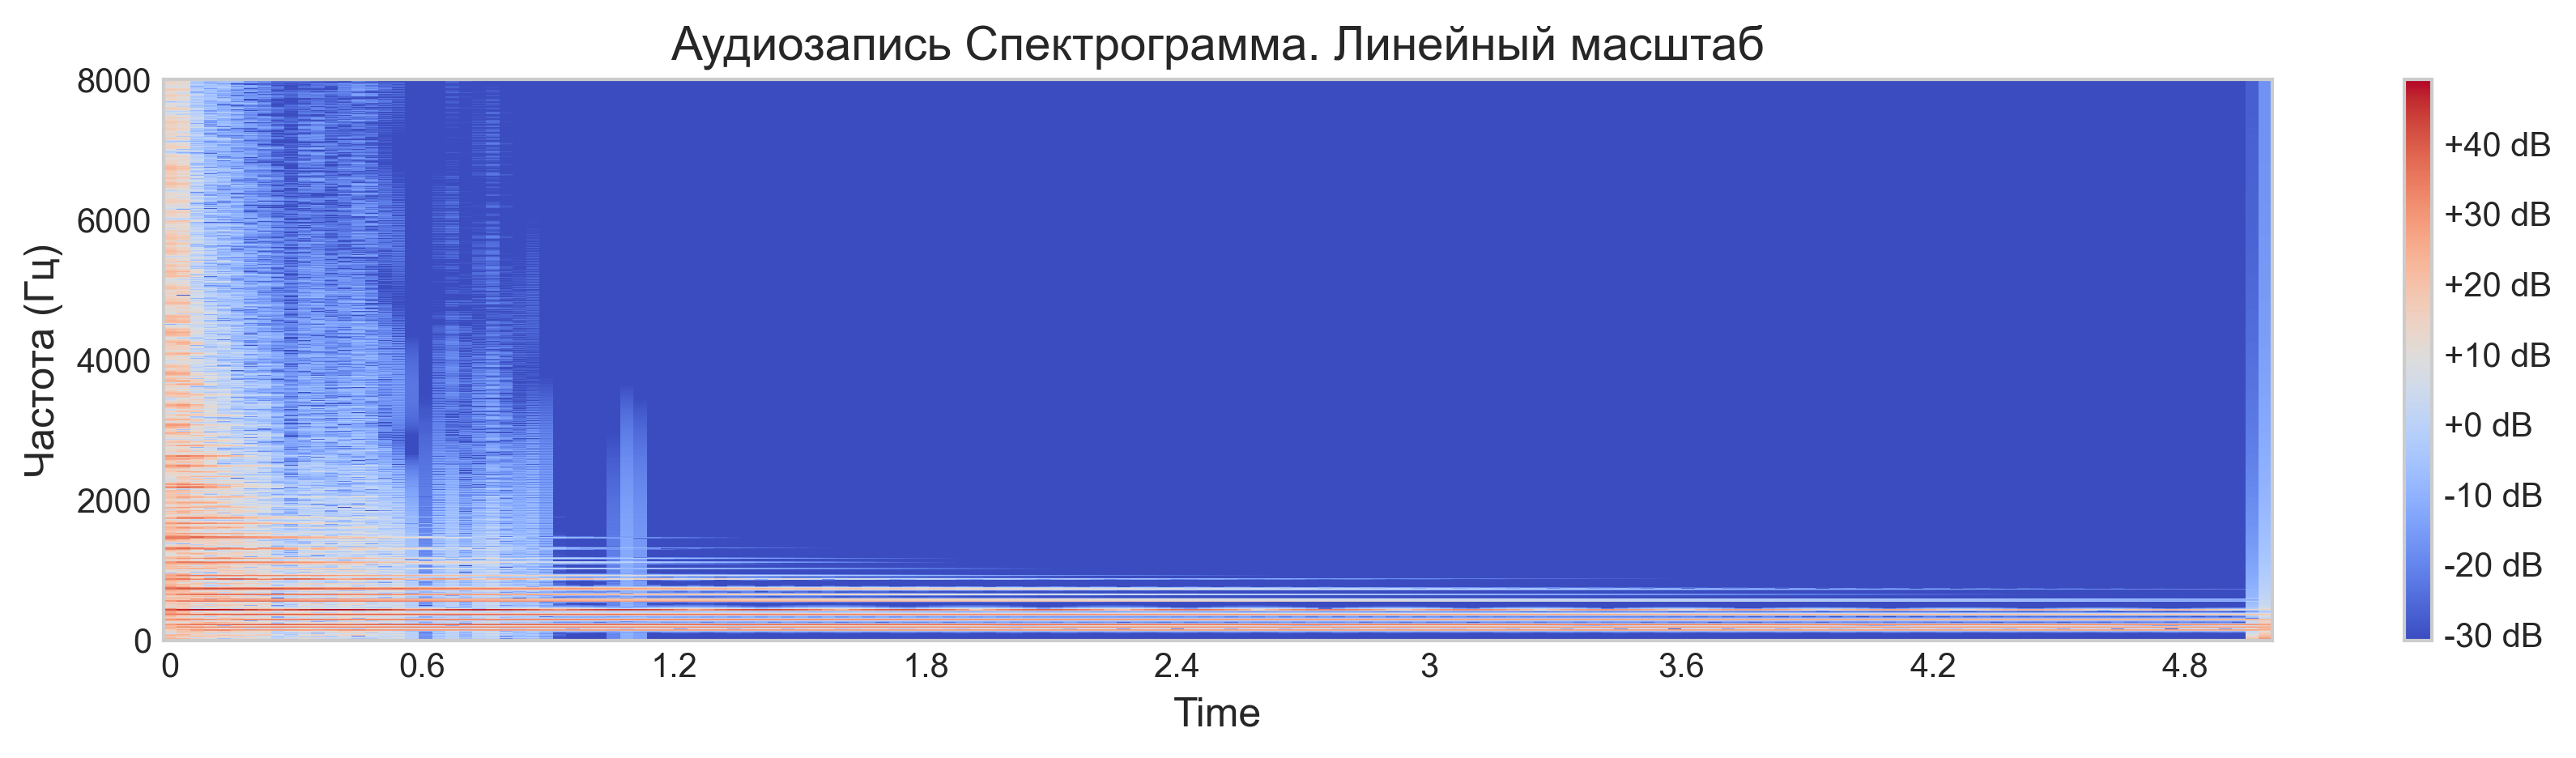

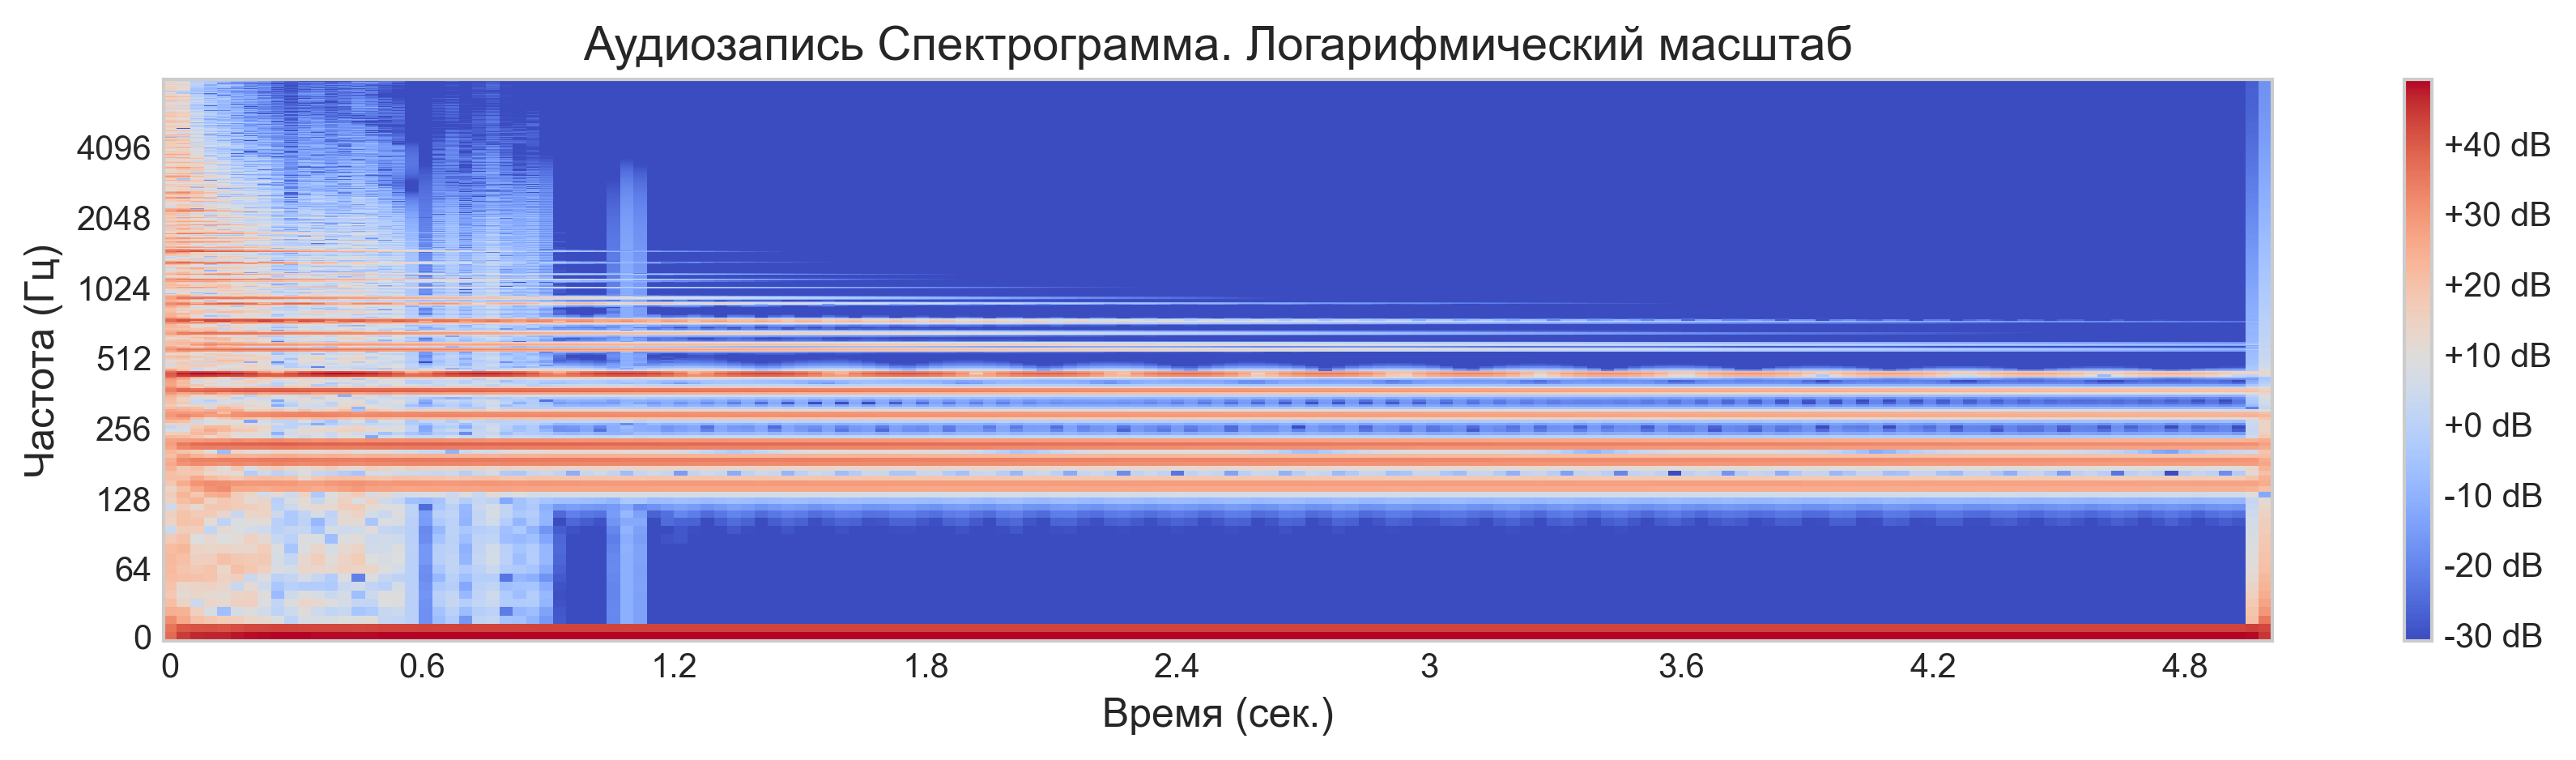

In [22]:
Spectrogram(audio_data, 'Аудиозапись', sr=original_sample_rate)

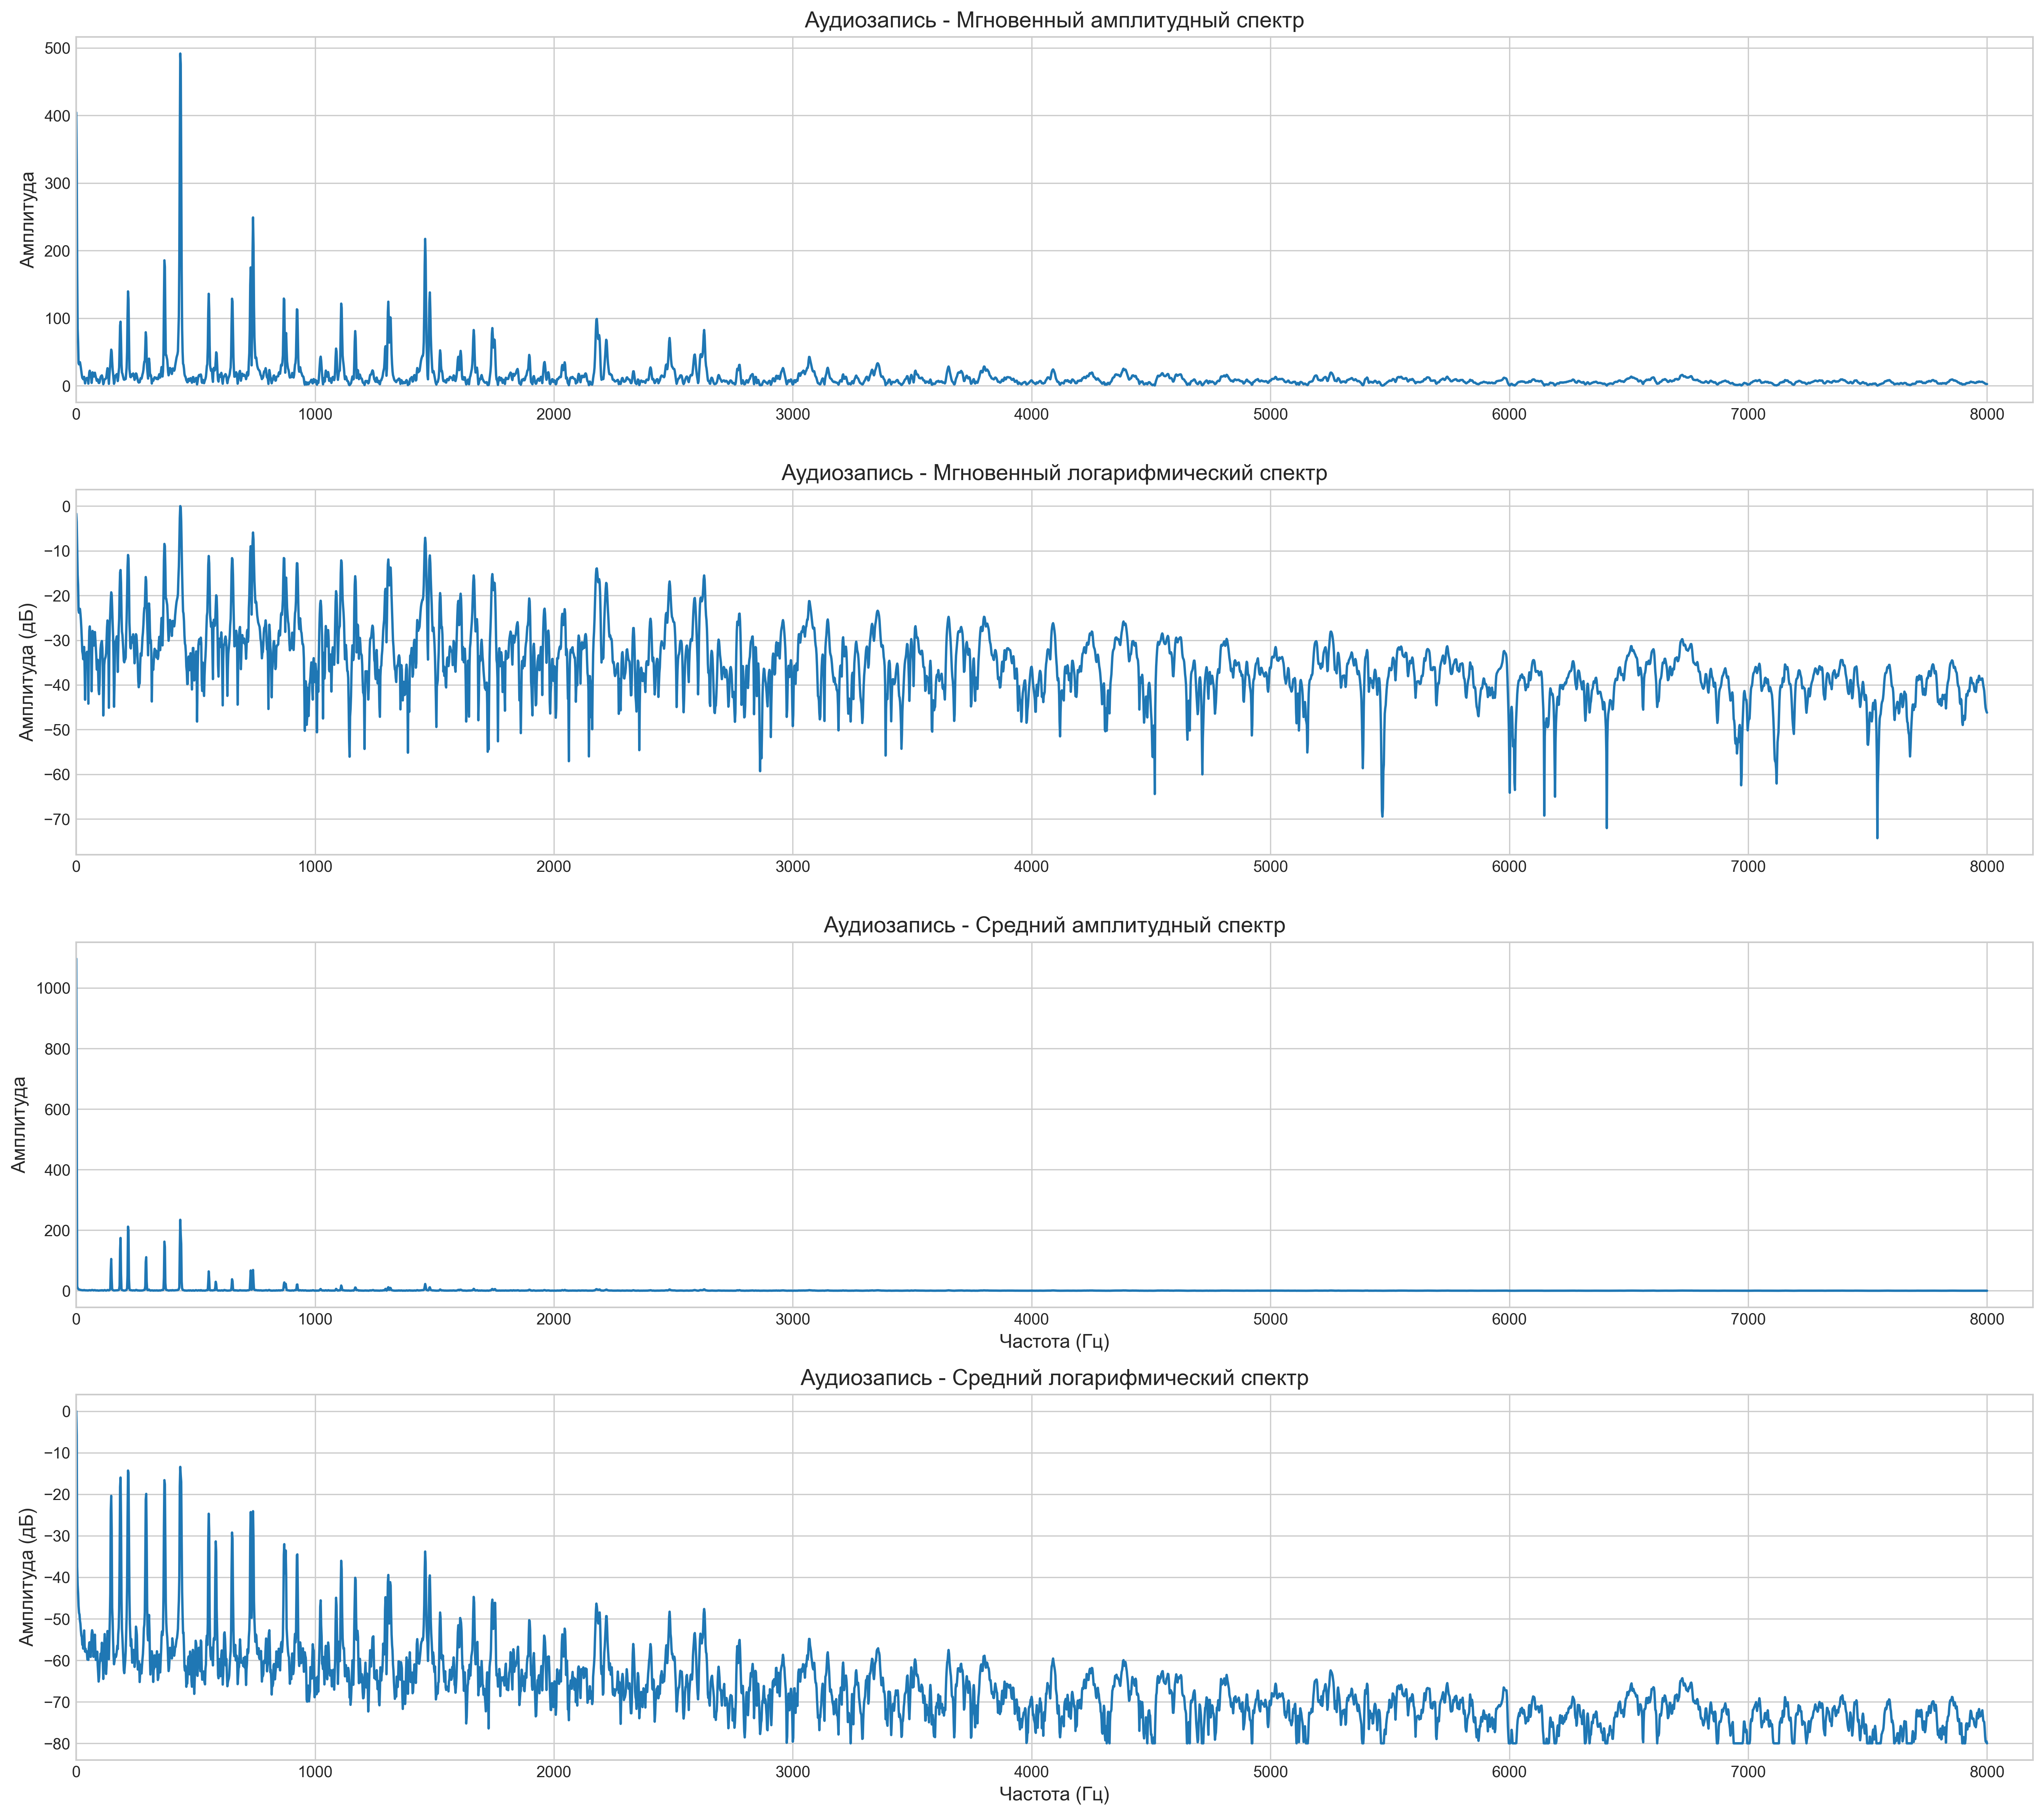

In [23]:
plot_spectra(audio_data, 
             name="Аудиозапись", 
             color="tab:blue", 
             n_fft=8192,
             sr=original_sample_rate,
             start=0,
             plot_instant=True, 
             plot_log=True,
             xlim_min=0, 
             xlim_max=8192
             )

### 1.2 Реализация


Вычислим усреднённый по времени логарифмический амплитудный спектр сигнала для выделения устойчивых частотных пиков

In [18]:
n_fft = 8192
freqs = librosa.fft_frequencies(sr=original_sample_rate, n_fft=n_fft)

# Средний спектр
sp = np.abs(librosa.stft(audio_data, n_fft=n_fft, hop_length=n_fft//4))
sp_mean = np.mean(sp, axis=1)
sp_mean_log = librosa.amplitude_to_db(sp_mean, ref=np.max)

Поиск пиков, до -50 дБ и получаем список пиков (кандидатов на частоты и их гармоники)

In [104]:
peaks, _ = find_peaks(sp_mean_log, height=-50, distance=5)
peak_freqs = freqs[peaks]
peak_sp_mean_log = sp_mean_log[peaks]

print("len: ", len(peak_freqs))
print("freqs:" , peak_freqs)


len:  32
freqs: [ 146.484375  185.546875  216.796875  292.96875   304.6875    369.140625
  435.546875  554.6875    583.984375  652.34375   730.46875   740.234375
  871.09375   925.78125  1023.4375   1087.890625 1109.375    1167.96875
 1294.921875 1306.640625 1460.9375   1480.46875  1523.4375   1607.421875
 1664.0625   1742.1875   1751.953125 2177.734375 2191.40625  2218.75
 2484.375    2628.90625 ]


In [125]:
def has_peak_near(freqs, target, tol_hz=5):
    return np.any(np.abs(freqs - target) < tol_hz)

def find_fundamentals(peak_freqs, peak_amps,
                      max_harmonic=5,
                      tol_hz=5,
                      min_harmonics=2):
    fundamentals = []

    for i, f0 in enumerate(peak_freqs):
        harmonics_found = 0

        for k in range(2, max_harmonic + 1):
            if has_peak_near(peak_freqs, k * f0, tol_hz):
                harmonics_found += 1

        if harmonics_found >= min_harmonics:
            fundamentals.append({
                "f0": f0,
                "strength": harmonics_found,
                "amp": peak_amps[i]
            })

    return fundamentals


In [229]:
fundamentals = find_fundamentals(
    peak_freqs,
    peak_sp_mean_log,
    max_harmonic=5,
    tol_hz= 3 * original_sample_rate / n_fft,
    min_harmonics=3
)
print(f"Найдено {len(fundamentals)} гармонических серий")

fundamentals.sort(key=lambda x: (x["strength"], x["amp"]), reverse=True)
fundamentals

Найдено 7 гармонических серий


[{'f0': np.float64(435.546875), 'strength': 4, 'amp': np.float32(-13.401718)},
 {'f0': np.float64(216.796875), 'strength': 4, 'amp': np.float32(-14.286461)},
 {'f0': np.float64(185.546875), 'strength': 4, 'amp': np.float32(-15.970528)},
 {'f0': np.float64(146.484375), 'strength': 4, 'amp': np.float32(-20.386936)},
 {'f0': np.float64(369.140625), 'strength': 3, 'amp': np.float32(-16.600517)},
 {'f0': np.float64(292.96875), 'strength': 3, 'amp': np.float32(-19.90963)},
 {'f0': np.float64(554.6875), 'strength': 3, 'amp': np.float32(-24.686665)}]

In [305]:
def detect_tonality(main_freqs, F0=130.82):
    # полутона относительно F0
    semitones = [round(12 * np.log2(f / F0)) for f in main_freqs]
    semitones.sort()

    base_shift  = semitones[0]
    intervals = tuple(s - base_shift  for s in semitones)

    if intervals == (0, 4, 7):
        quality = "major"
    elif intervals == (0, 3, 7):
        quality = "minor"
    else:
        quality = None

    tonic_pc = base_shift % 12
    return tonic_pc, quality, intervals, semitones

def best_triad_by_intervals(fundamentals, top_n=10, F0=130.82):
    """
    Перебираем комбинации из топ-N фундаменталов и выбираем тройку,
    которая ближе всего к (0,3,7) или (0,4,7) по сумме квадратов ошибок.
    """
    cands = [float(x["f0"]) for x in fundamentals[:top_n]]
    if len(cands) < 3:
        return None

    best = None
    targets = [(0, 3, 7), (0, 4, 7)]

    for i in range(len(cands)):
        for j in range(i + 1, len(cands)):
            for k in range(j + 1, len(cands)):
                tri = sorted([cands[i], cands[j], cands[k]])
                semis = [round(12 * np.log2(f / F0)) for f in tri]
                semis.sort()
                base = semis[0]
                ints = tuple(s - base for s in semis)

                # считаем ошибку до ближайшего шаблона
                errs = [sum((ints[m] - t[m]) ** 2 for m in range(3)) for t in targets]
                err = min(errs)

                # критерий: минимальная ошибка, а при равенстве - выше средняя амплитуда
                if best is None or err < best["err"]:
                    best = {"err": err, "freqs": tri, "intervals": ints}

    return best

In [245]:
def freq_to_note_C3(freq, F0=130.82):
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    
    n = int(round(12 * np.log2(freq / F0)))
    note = notes[n % 12]
    octave = 3 + (n // 12)  # потому что F0 соответствует C3
    return f"{note}{octave}"


In [272]:
fallback = best_triad_by_intervals(fundamentals, top_n=10, F0=130.82)

main_freqs_fb = fallback["freqs"]
tonic_fb, quality_fb, intervals_fb, semitones_fb = detect_tonality(main_freqs_fb, F0=130.82)

print("Лучшая тройка по интервалам:")
for i, f in enumerate(main_freqs_fb, 1):
    print(f"  F{i}: {freq_to_note_C3(f)} ({f:.1f} Гц)")

notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
notes_ru = ['До', 'До#', 'Ре', 'Ре#', 'Ми', 'Фа', 'Фа#', 'Соль', 'Соль#', 'Ля', 'Ля#', 'Си']
triad_numbers = (tonic_fb + intervals_fb[0], tonic_fb + intervals_fb[1], tonic_fb + intervals_fb[2])

print()
print(f"Интервалы: {intervals_fb}")
print(f"Трезвучие: {triad_numbers}")
print(f"Тональность: {notes[tonic_fb]} {quality_fb} | {notes_ru[tonic_fb]} {quality_fb}")



Лучшая тройка по интервалам:
  F1: D4 (293.0 Гц)
  F2: F#4 (369.1 Гц)
  F3: A4 (435.5 Гц)

Интервалы: (0, 4, 7)
Трезвучие: (2, 6, 9)
Тональность: D major | Ре major


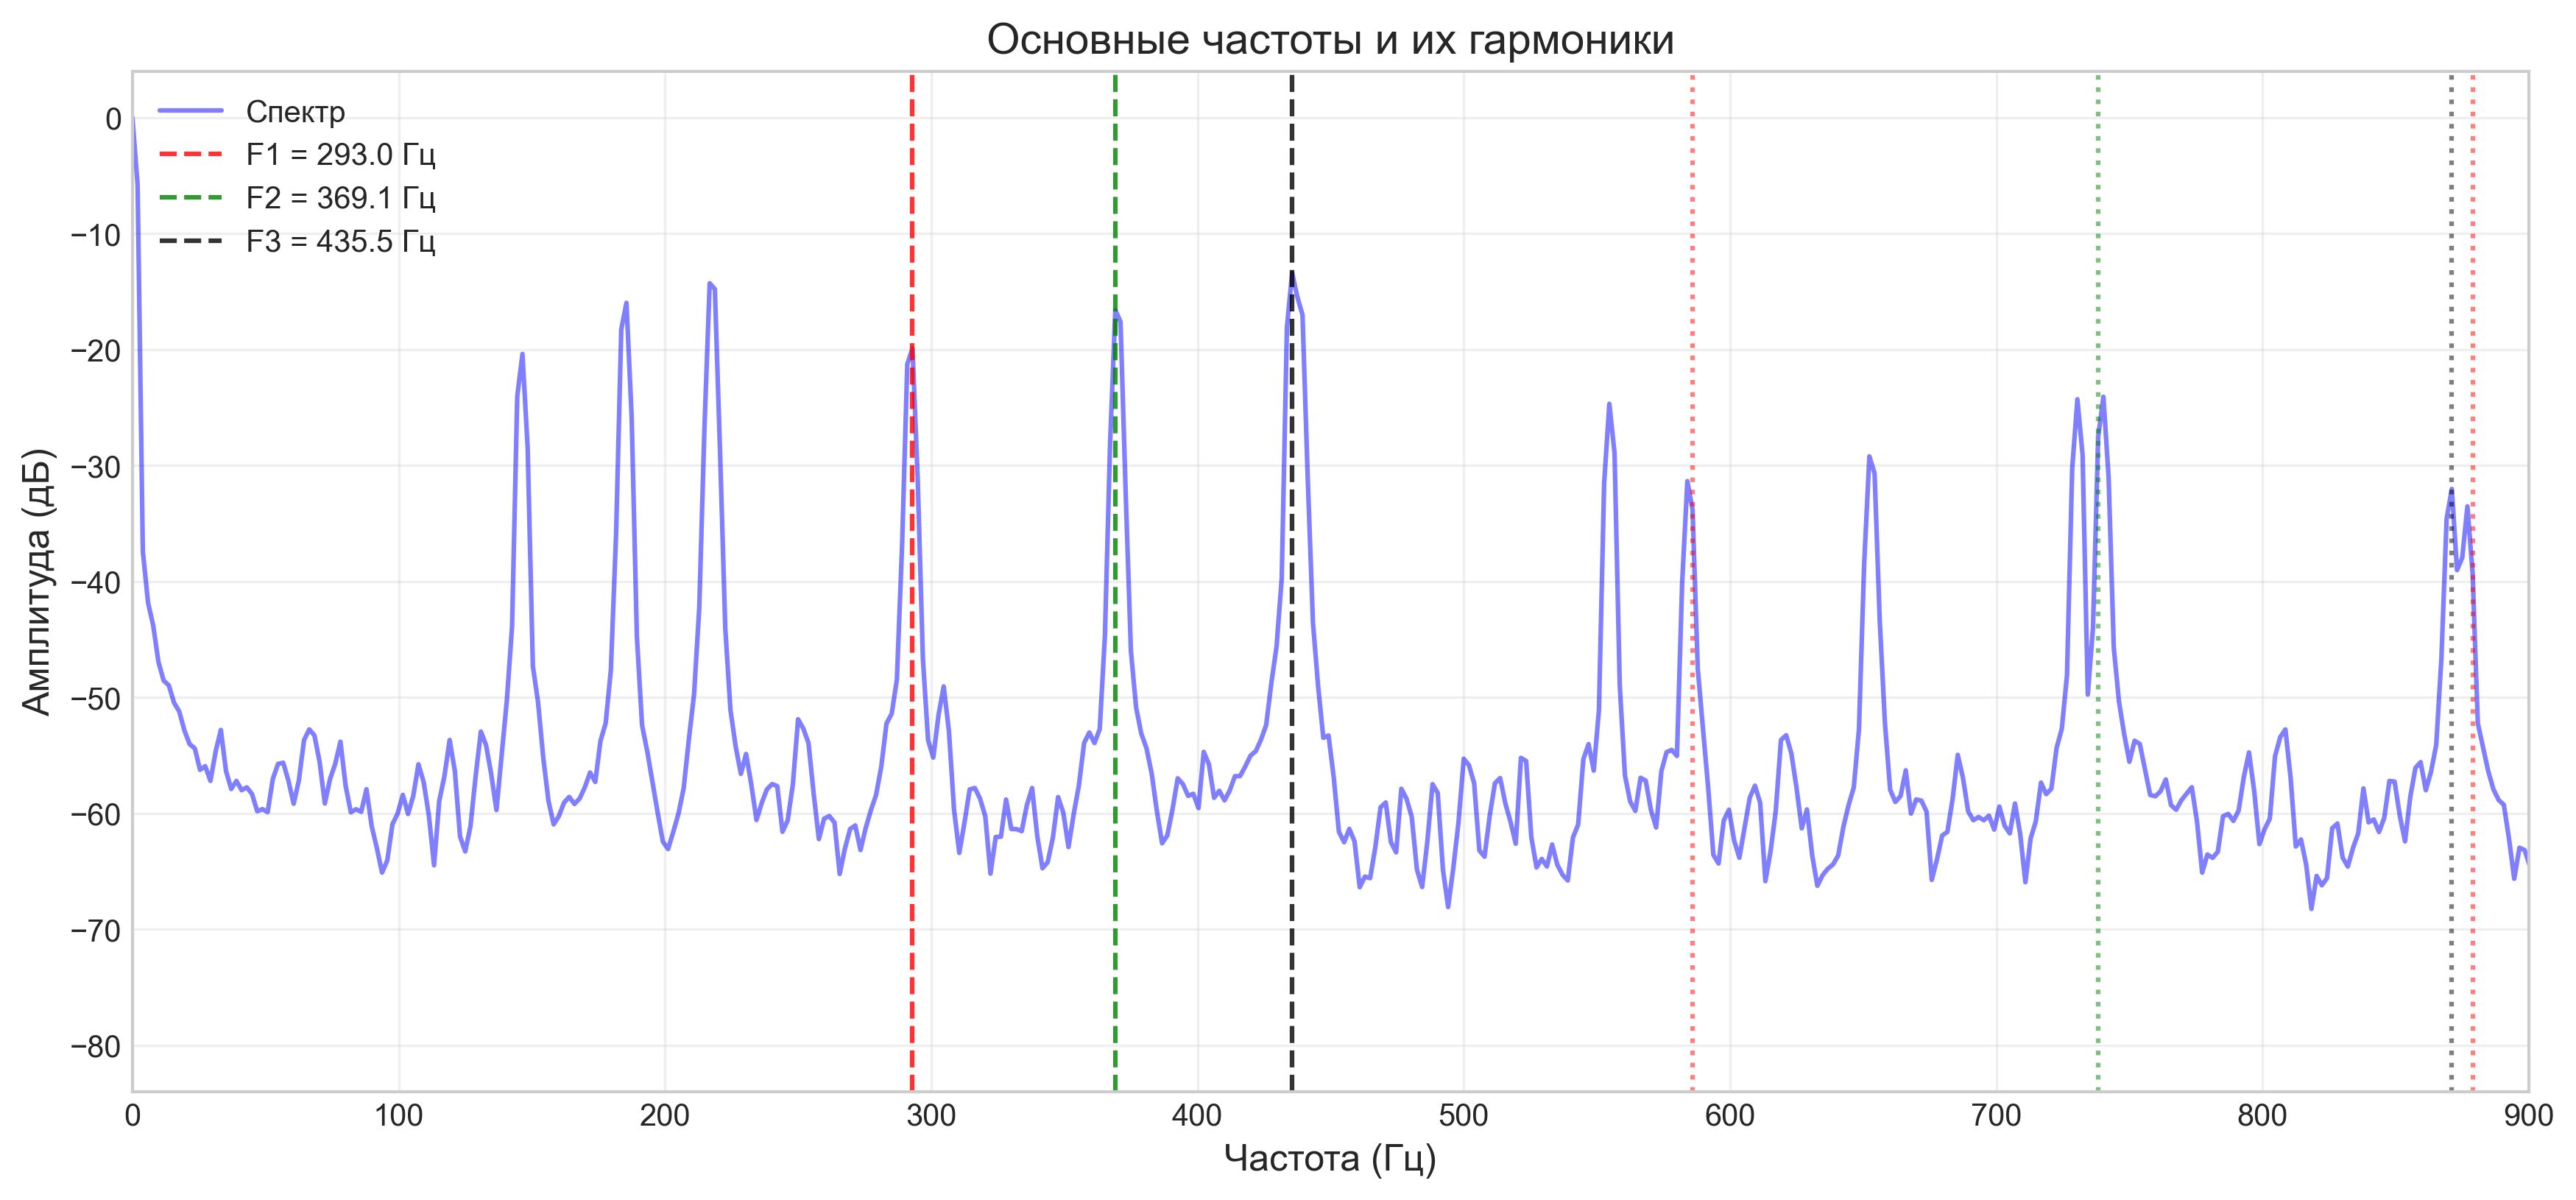

In [304]:
# Визуализация гармонических серий
plt.figure(figsize=(14, 6))

plt.plot(freqs, sp_mean_log, color="blue", alpha=0.5, label='Спектр')
plt.title("Основные частоты и их гармоники")
plt.xlabel("Частота (Гц)")
plt.ylabel("Амплитуда (дБ)")
plt.grid(True, alpha=0.3)

line_colors = ["red", "green", "black"]
for i in range(3):
    f0 = main_freqs_fb[i]
    c = line_colors[i]

    # Основная частота
    plt.axvline(f0, color=c, linestyle="--", alpha=0.8, label=f'F{i+1} = {f0:.1f} Гц')

    # Гармоники 2F, 3F
    for h in [2, 3]:
        fh = f0 * h
        plt.axvline(fh, color=c, linestyle=":", alpha=0.5)

# Ограничим ось X
plt.xlim(0, 900)
plt.legend()
plt.show()

## Найденное трезвучие: ре-мажор (D major)